In [1]:
import sys

import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm as tqdm_auto
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import pytorch_lightning as pl

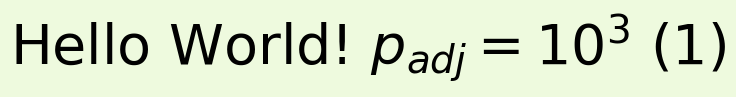

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


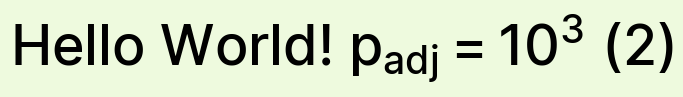

In [2]:
def print_text(text):
    fig, ax = plt.subplots(figsize=(6, 1), facecolor="#eefade")
    ax.text(0.5, 0.5, text, ha='center', va='center', size=40)
    ax.axis("off")
    plt.show()

print_text("Hello World! $p_{adj}=10^3$ (1)")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams["font.sans-serif"] = ["Inter"]
plt.rcParams["font.weight"] = "medium"
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['svg.fonttype'] = 'none'
print_text("Hello World! $p_{adj}=10^3$ (2)")

In [3]:
SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=BIGGER_SIZE, labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=MEDIUM_SIZE)
plt.rc('figure', titlesize=BIGGER_SIZE)

In [4]:
palette_light = sns.color_palette(["#F15854","#FAA43A","#E5D00D","#60BD68","#5DA5DA","#F17CB0","#975597","#B2912F","#AAAAAA","#4D4D4D"])
palette_dark = sns.color_palette(["#B8202B","#C27500","#AF9F00","#2B8C3B","#1F76A8","#BC4B81","#672969","#7F6400","#7B7B7B","#252525"])
sns.set_palette(palette_light + palette_dark)
sns.color_palette(palette_light + palette_dark)

[(0.9450980392156862, 0.34509803921568627, 0.32941176470588235),
 (0.9803921568627451, 0.6431372549019608, 0.22745098039215686),
 (0.8980392156862745, 0.8156862745098039, 0.050980392156862744),
 (0.3764705882352941, 0.7411764705882353, 0.40784313725490196),
 (0.36470588235294116, 0.6470588235294118, 0.8549019607843137),
 (0.9450980392156862, 0.48627450980392156, 0.6901960784313725),
 (0.592156862745098, 0.3333333333333333, 0.592156862745098),
 (0.6980392156862745, 0.5686274509803921, 0.1843137254901961),
 (0.6666666666666666, 0.6666666666666666, 0.6666666666666666),
 (0.30196078431372547, 0.30196078431372547, 0.30196078431372547),
 (0.7215686274509804, 0.12549019607843137, 0.16862745098039217),
 (0.7607843137254902, 0.4588235294117647, 0.0),
 (0.6862745098039216, 0.6235294117647059, 0.0),
 (0.16862745098039217, 0.5490196078431373, 0.23137254901960785),
 (0.12156862745098039, 0.4627450980392157, 0.6588235294117647),
 (0.7372549019607844, 0.29411764705882354, 0.5058823529411764),
 (0.403921568627451, 0.1607843137254902, 0.4117647058823529),
 (0.4980392156862745, 0.39215686274509803, 0.0),
 (0.4823529411764706, 0.4823529411764706, 0.4823529411764706),
 (0.1450980392156863, 0.1450980392156863, 0.1450980392156863)]

In [5]:
sys.path.append("../../predictor/model")
import utrdata_cl as utrdata
import stability_data
from legnet import LegNetClassifier
from pl_regressor import RNARegressor

In [6]:
model_act = RNARegressor.load_from_checkpoint("../../predictor/regression_multiple/saved_models/model-utr3-deltas-epoch=9-step=1330.ckpt")
model_stb = RNARegressor.load_from_checkpoint("../../predictor/regression_stability/saved_models/stability-epoch=24-step=725.ckpt")

In [7]:
with open("./parade_stable_utr.fa", "rt") as handle:
    _, sequence = [s.strip() for s in handle.readlines()]
sequence

'AACGGGGCCGACGGCTTGAGACCCAACTGGCACCGCCGGCAACGCGGCATTGCACTTATCGCCCGCCGTTAGACGGAAAGGCAGCCCGCAAGACGCGCCGGAAAGCCCGCCGATACAGAATGCCGAACAACAAGAAACAAAGCGAGCACAACAACCACGACAACACGAACGCCAAAAAGGAGCATTGTGACACCCCCCGCTGGAAACAATCAATCGACAGGAAACCGTCCAAACGCACGATAGTTTTCTATGCTCATTTCAACTTGGCTTTTTGTCTTTTAAATTTTTAAAAAATGCAGTAGTCCGTGTTCCATCCTCCACGCACCCCCACCTATCGTTGGTTCGCAAAGTGCAAAGCTTTCTGTAATAAGAAAATTAAATTTTCTGTTCTAGTTTTTTCTGTAATCATAAGCATTCTGATTTCTCTTTCAAGTAGTTGTAAATAATCTCTTTTTCTCATATAAACGGAATGCATAATGTTTGGAAGTATATTTGGGGGTTGGGTCTTTTTGTTAAACTCTGGATAGTAATAAGTTTCAGGTTTGGATACTTAATTTGTAGTTTCAATTTTGATTTCTCCTGTGAACTAGGAATTATGTG'

In [8]:
def prepare_df(seq, window=240, step=1, add_cell_lines=None, add_dummies=None):
    shift = list(range(0, len(seq) - window + 1, step))
    slices = [seq[i:i + window] for i in shift]
    df = pd.DataFrame({
        "shift": shift,
        "window_center": [i + window // 2 for i in shift],
        "seq": slices,
    })
    if add_cell_lines is not None:
        ctdf = pd.Series(add_cell_lines, name="cell_type")
        df = df.merge(ctdf, how="cross")  # Cartesian product of dataframes
    if add_dummies is not None:
        for col in add_dummies:
            df[col] = 0.0
    return df

In [9]:
df_activity = prepare_df(sequence, window=240, step=1, add_cell_lines=['c1', 'c2', 'c4', 'c6', 'c17', 'c13'],
                         add_dummies=['diff', 'mass_center'])
df_stability = prepare_df(sequence, window=186, step=1,
                          add_dummies=['RNA/gDNA'])

In [10]:
# Creating DataLoaders
dl_activity = DataLoader(
    utrdata.UTRData(
        df=df_activity,
        features=("sequence", "positional", "conditions"),
        construct_type="utr3",
        augment=False,
        augment_test_time=False,
        augment_kws=dict(
            extend_left=0,
            extend_right=0,
            shift_left=0,
            shift_right=0,
            revcomp=False,
        ),
    ),
    batch_size=256,
    num_workers=16,
    shuffle=False,
    drop_last=False,
)
dl_stability = DataLoader(
    stability_data.StabilityData(
        df=df_stability,
        features=("sequence",),
    ),
    batch_size=256,
    num_workers=16,
    shuffle=False,
    drop_last=False,
)

In [11]:
progressbar_callback = pl.callbacks.TQDMProgressBar(refresh_rate=0.5)
trainer = pl.Trainer(
    callbacks=[progressbar_callback],
    logger=False,
    accelerator="gpu",
    devices=1,
    deterministic=True,
    # gradient_clip_val=1e-5,
    # gradient_clip_algorithm="norm",
)
prediction_act = trainer.predict(model=model_act, dataloaders=dl_activity)
prediction_act, _ = zip(*prediction_act)
prediction_act = torch.concat(prediction_act).numpy()
df_activity["pred_activity"] = prediction_act[:, 1]
df_activity["pred_delta"] = prediction_act[:, 0]

prediction_stb = trainer.predict(model=model_stb, dataloaders=dl_stability)
prediction_stb, _ = zip(*prediction_stb)
prediction_stb = torch.concat(prediction_stb).numpy()
df_stability["pred_stability"] = prediction_stb[:, 0]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting: 0it [00:00, ?it/s]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting: 0it [00:00, ?it/s]

In [12]:
windowsize = 50
gc = prepare_df(sequence, window=windowsize, step=1)
gc["C"] = gc["seq"].str.count("C") / windowsize
gc["G"] = gc["seq"].str.count("G") / windowsize
gc["GC"] = gc["C"] + gc["G"]

In [13]:
df_activity["window_center_codon"] = df_activity["window_center"] // 3 * 3
activity = df_activity.groupby("window_center_codon")["pred_activity"].mean()
stability = df_stability.set_index("window_center")["pred_stability"]
gc_content = gc.set_index("window_center")["GC"]

In [14]:
min_x = max(activity.index.min(), stability.index.min(), gc_content.index.min()) - 1
max_x = min(activity.index.max(), stability.index.max(), gc_content.index.max()) + 1
activity = activity.loc[min_x:max_x]
stability = stability.loc[min_x:max_x]
gc_content = gc_content.loc[min_x:max_x]

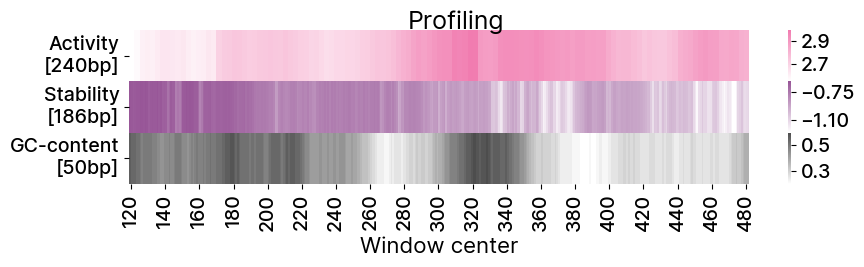

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(10, 2))
plt.suptitle("Profiling", ha="right")
sns.heatmap(activity.to_frame().T, cmap=sns.color_palette("blend:white,C5", as_cmap=True), ax=axes[0],
            cbar_kws=dict(ticks=[2.7, 2.9]))
axes[0].set_xticks([])
axes[0].set_yticklabels(["Activity\n[240bp]"], rotation=0)
sns.heatmap(stability.to_frame().T, cmap=sns.color_palette("blend:white,C6", as_cmap=True), ax=axes[1],
            cbar_kws=dict(ticks=[-1.1, -0.75]))
axes[1].set_xticks([])
axes[1].set_yticklabels(["Stability\n[186bp]"], rotation=0)
sns.heatmap(gc_content.to_frame().T, cmap=sns.color_palette("blend:white,C9", as_cmap=True), ax=axes[2],
            cbar_kws=dict(ticks=[0.3, 0.5]))
axes[2].set_xticks(np.arange(1, gc_content.shape[0], 20))
axes[2].set_xticklabels(gc_content.index[1::20])
axes[2].set_yticklabels(["GC-content\n[50bp]"], rotation=0)
axes[2].set_xlabel("Window center")
fig.subplots_adjust(hspace=0)
fig.savefig("profiling.svg", dpi=600)